<a href="https://www.kaggle.com/code/omborse771924/yeast-eda-features-engineering-66-accuracy?scriptVersionId=331246752" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samanemami/yeastcsv/yeast.csv


## Loading Dataset


In [2]:
df = pd.read_csv('/kaggle/input/datasets/samanemami/yeastcsv/yeast.csv')

In [3]:
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,name
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [4]:
df.tail()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,name
1479,0.81,0.62,0.43,0.17,0.5,0.0,0.53,0.22,ME2
1480,0.47,0.43,0.61,0.40,0.5,0.0,0.48,0.47,NUC
1481,0.67,0.57,0.36,0.19,0.5,0.0,0.56,0.22,ME2
1482,0.43,0.40,0.60,0.16,0.5,0.0,0.53,0.39,NUC
1483,0.65,0.54,0.54,0.13,0.5,0.0,0.53,0.22,CYT


In [5]:
df.describe()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.500121,0.499933,0.500034,0.261186,0.504717,0.007500,0.499885,0.276199
std,0.137299,0.123924,0.086670,0.137098,0.048351,0.075683,0.057797,0.106491
min,0.110000,0.130000,0.210000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,0.410000,0.420000,0.460000,0.170000,0.500000,0.000000,0.480000,0.220000
50%,0.490000,0.490000,0.510000,0.220000,0.500000,0.000000,0.510000,0.220000
75%,0.580000,0.570000,0.550000,0.320000,0.500000,0.000000,0.530000,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.830000,0.730000,1.000000


In [6]:
df.isnull()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,name
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1479,False,False,False,False,False,False,False,False,False
1480,False,False,False,False,False,False,False,False,False
1481,False,False,False,False,False,False,False,False,False
1482,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

mcg     0
gvh     0
alm     0
mit     0
erl     0
pox     0
vac     0
nuc     0
name    0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1479    False
1480    False
1481    False
1482    False
1483    False
Length: 1484, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(31)

In [10]:
df.columns

Index(['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc', 'name'], dtype='object')

## EDA


    mcg   gvh   alm   mit  erl  pox   vac   nuc name
0  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22  MIT
1  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22  MIT
2  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22  MIT
3  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22  NUC
4  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22  MIT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     1484 non-null   float64
 1   gvh     1484 non-null   float64
 2   alm     1484 non-null   float64
 3   mit     1484 non-null   float64
 4   erl     1484 non-null   float64
 5   pox     1484 non-null   float64
 6   vac     1484 non-null   float64
 7   nuc     1484 non-null   float64
 8   name    1484 non-null   object 
dtypes: float64(8), object(1)
memory usage: 104.5+ KB
None
               mcg          gvh          alm          mit          erl  \
count  1484.000000  1484.000000  148

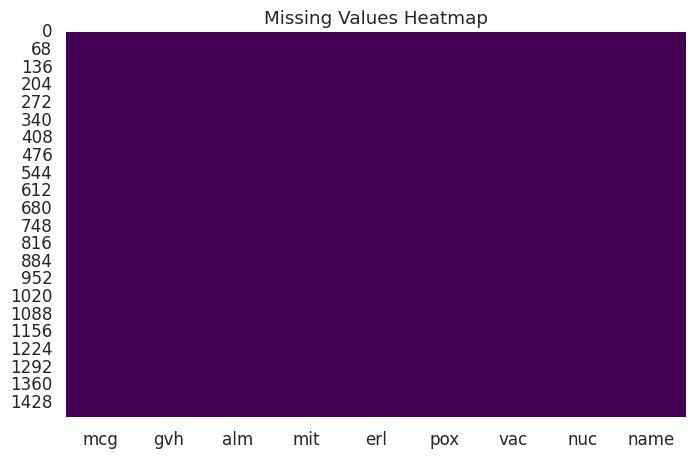

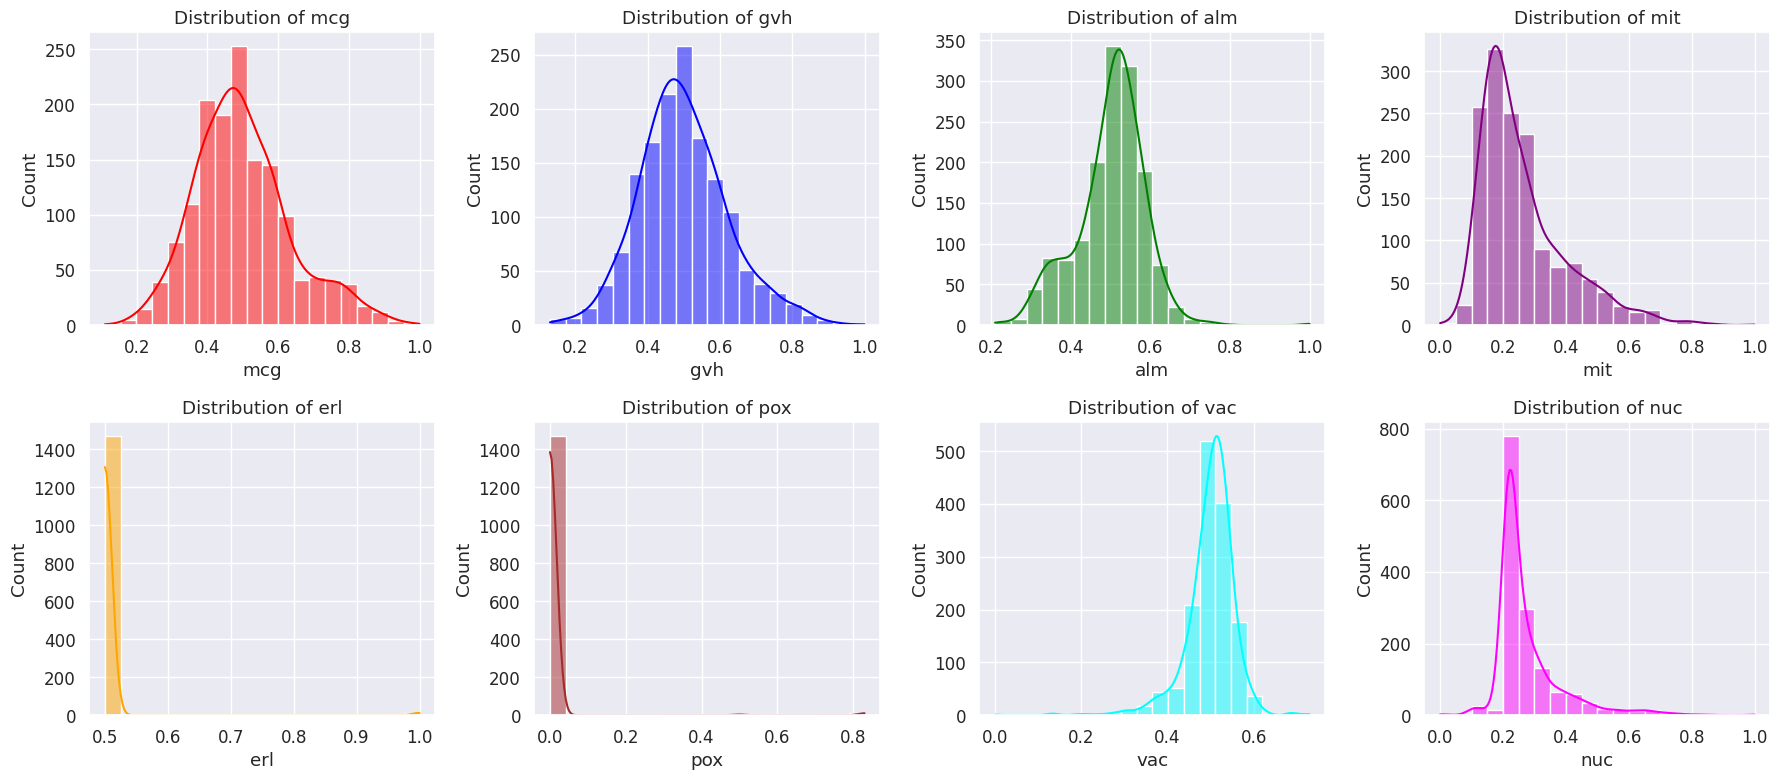

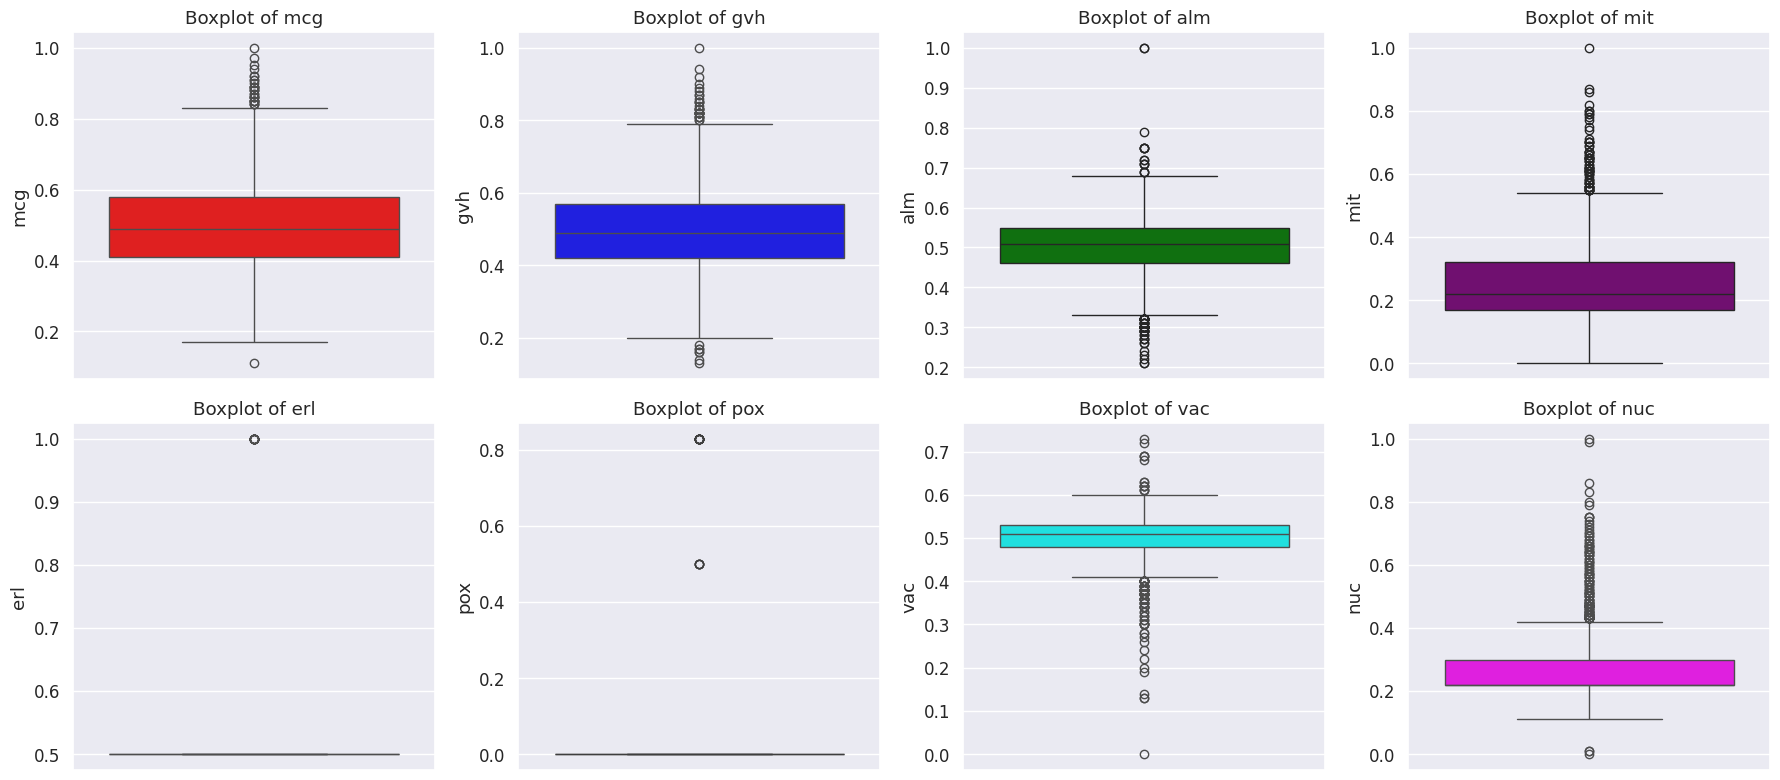

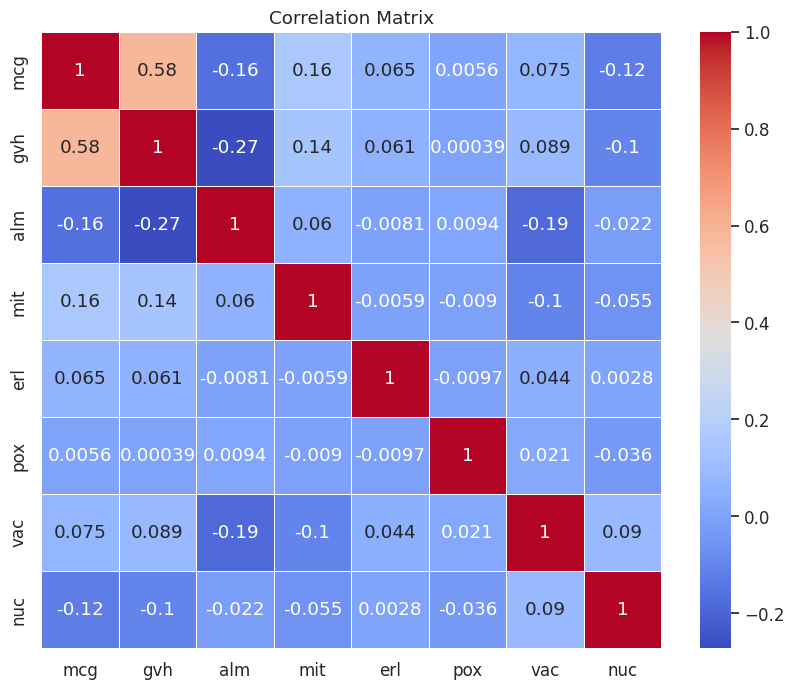

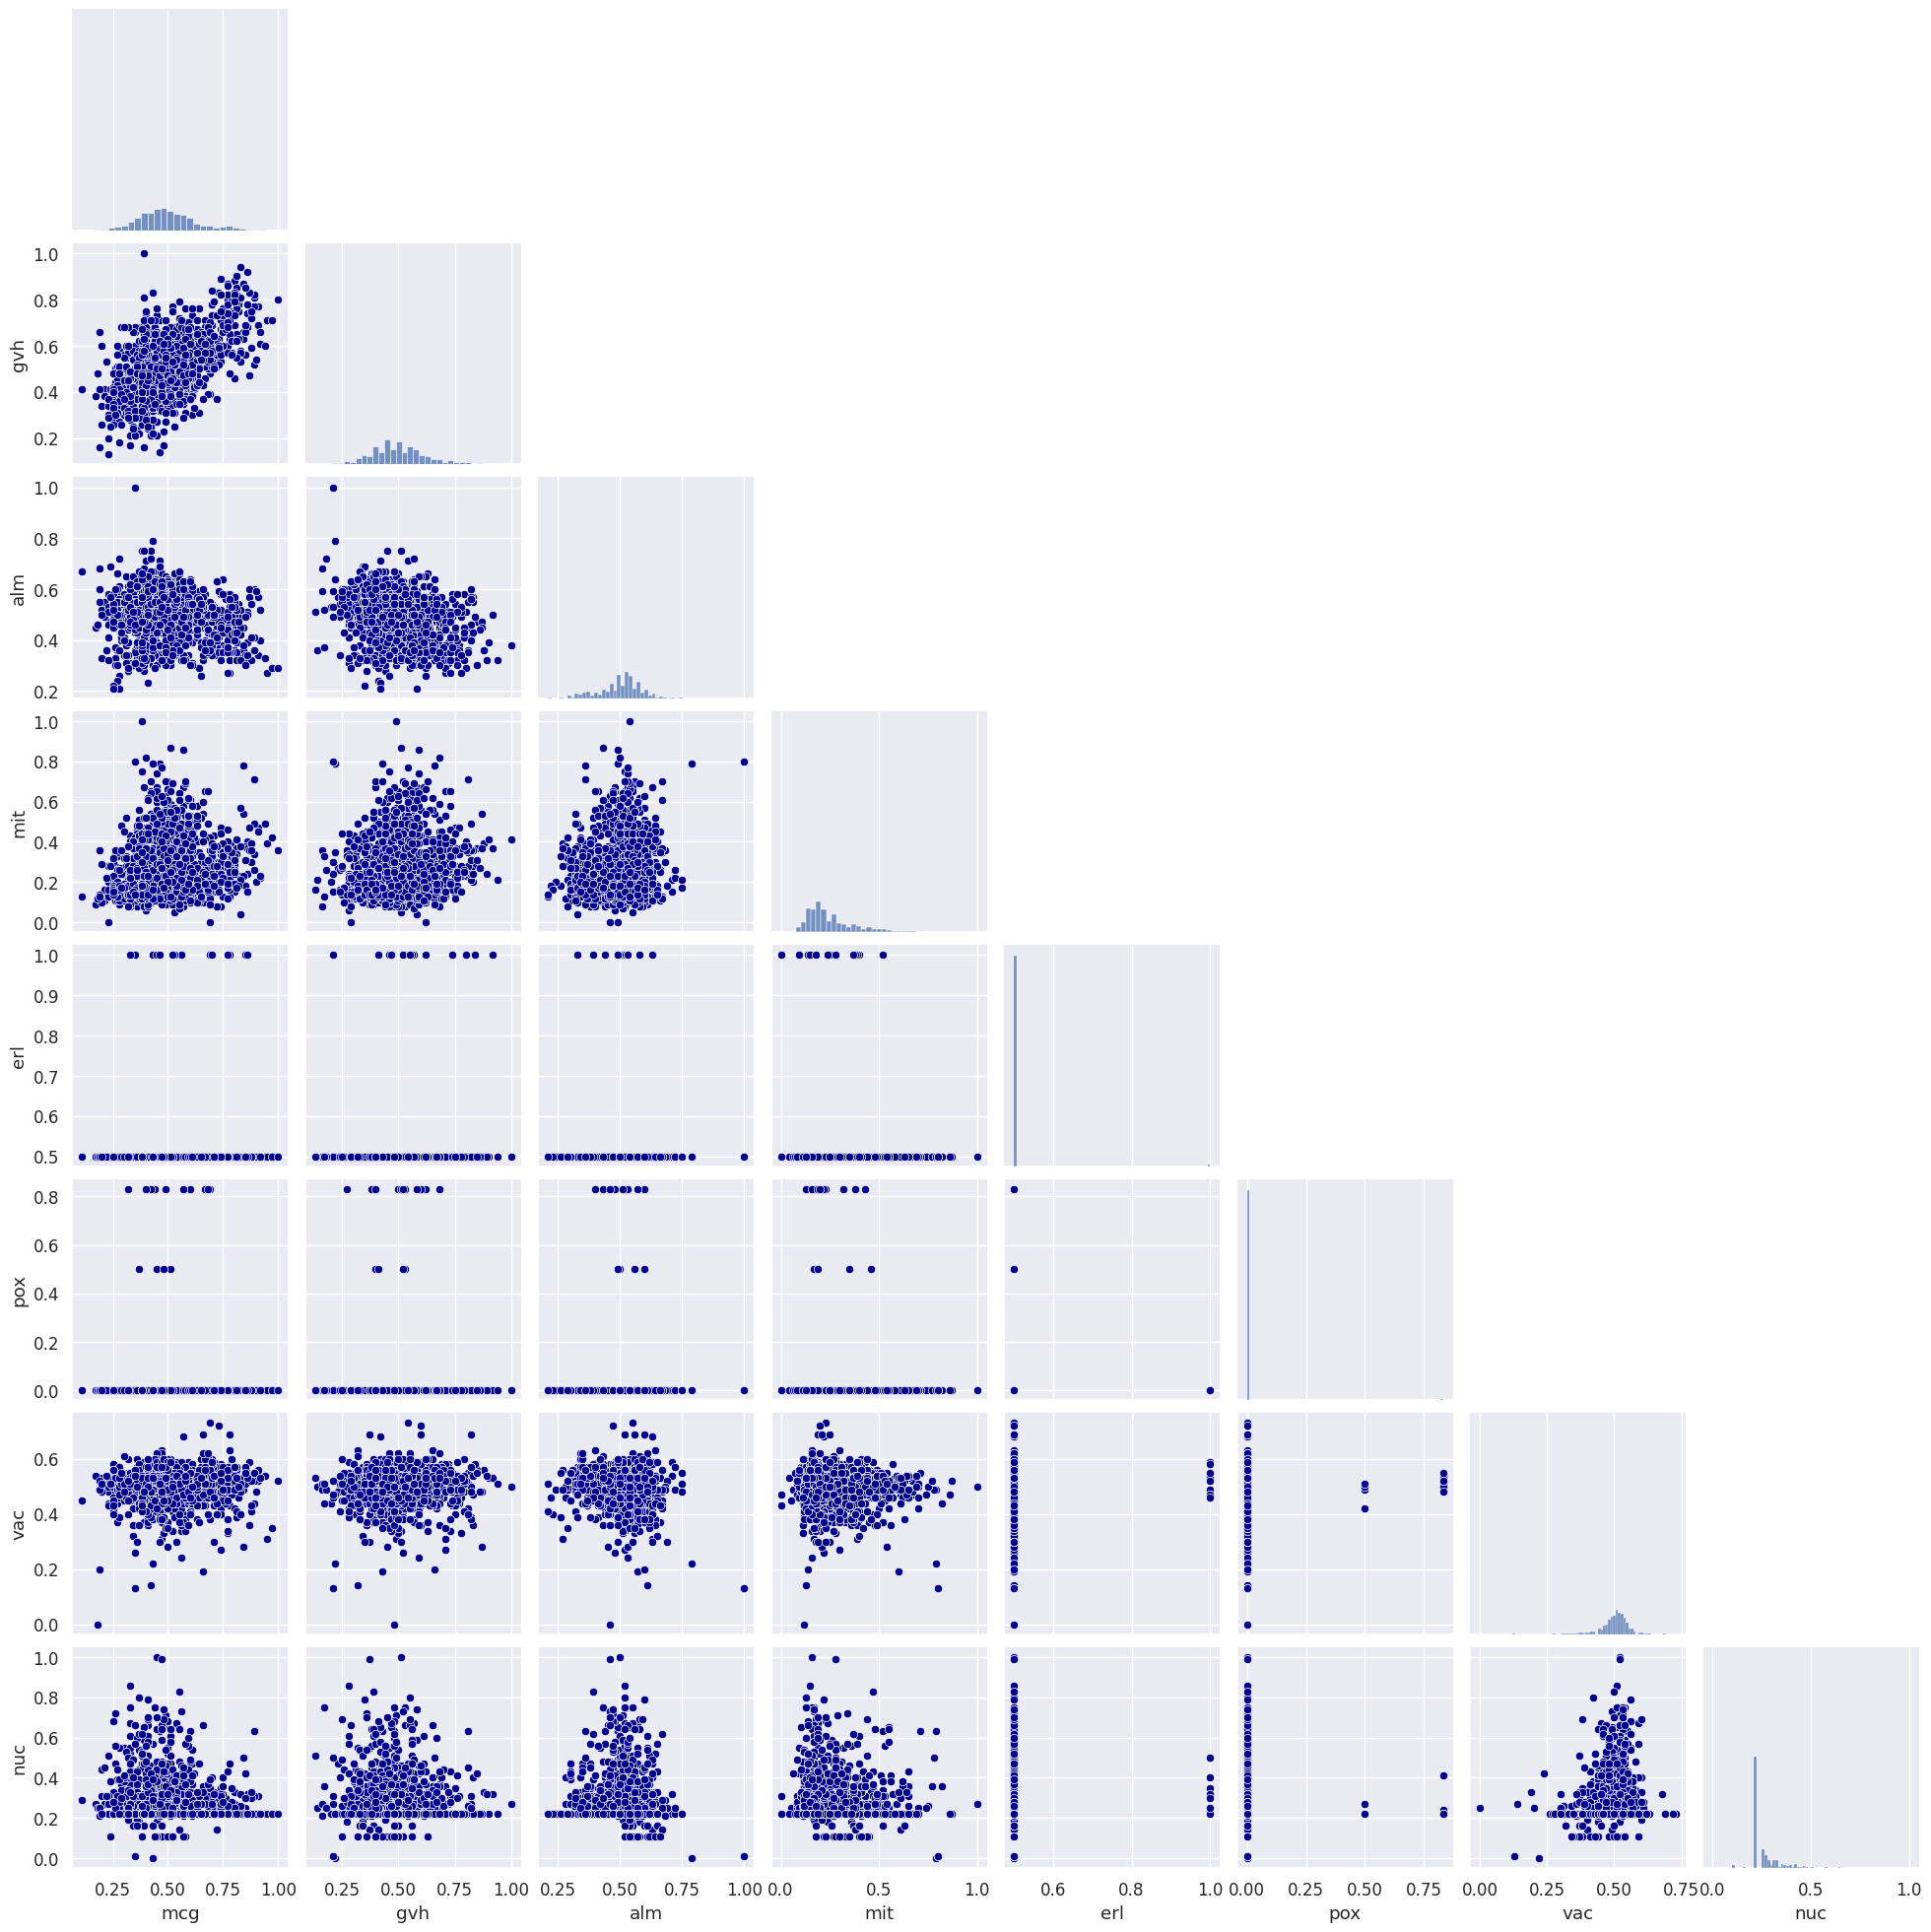

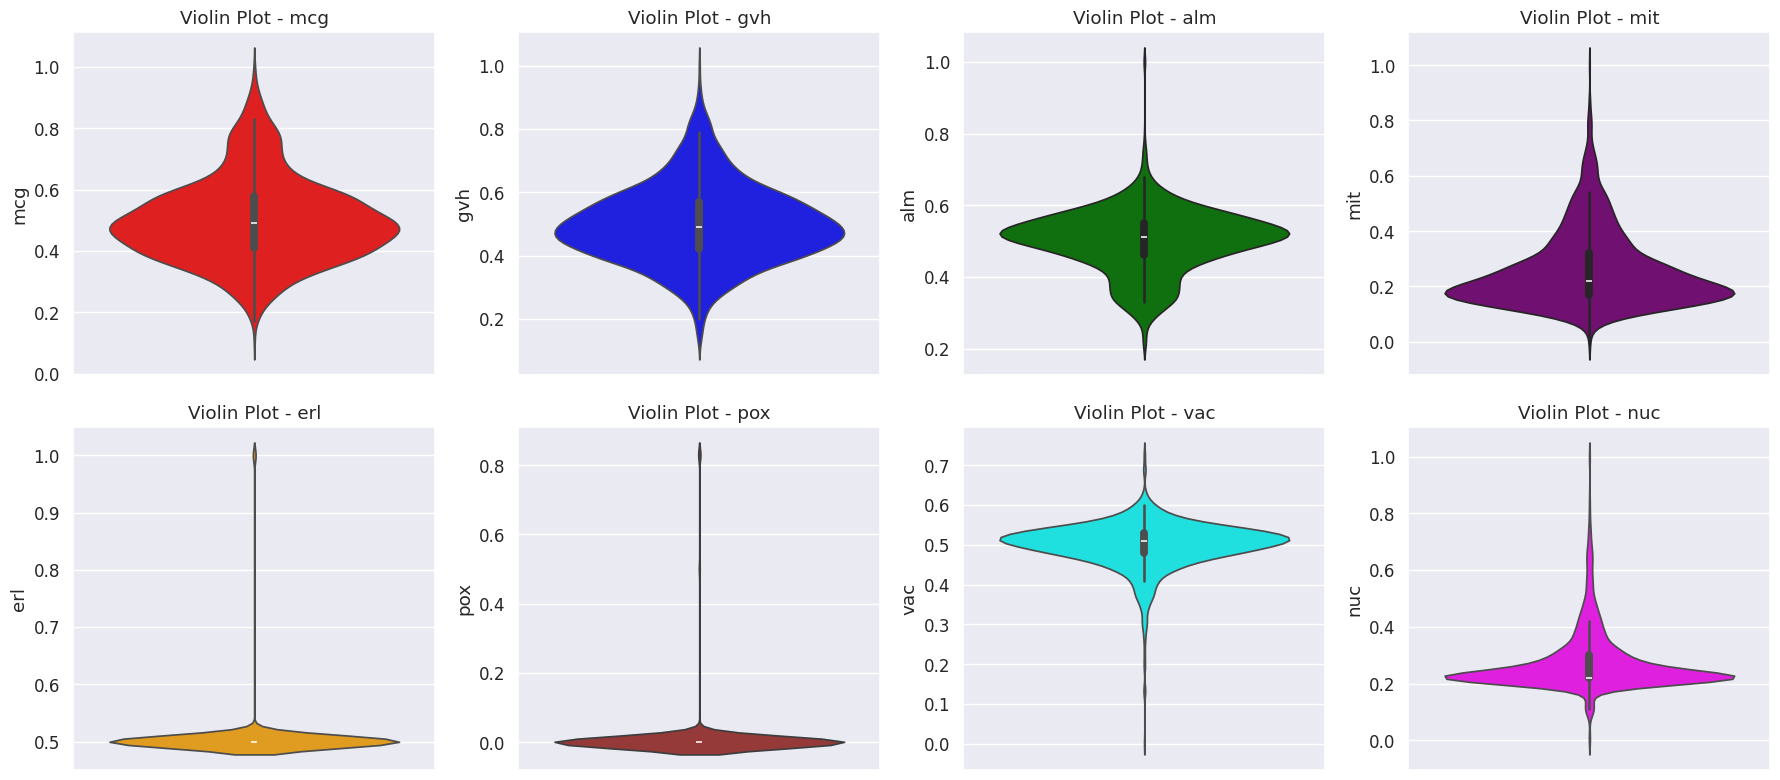

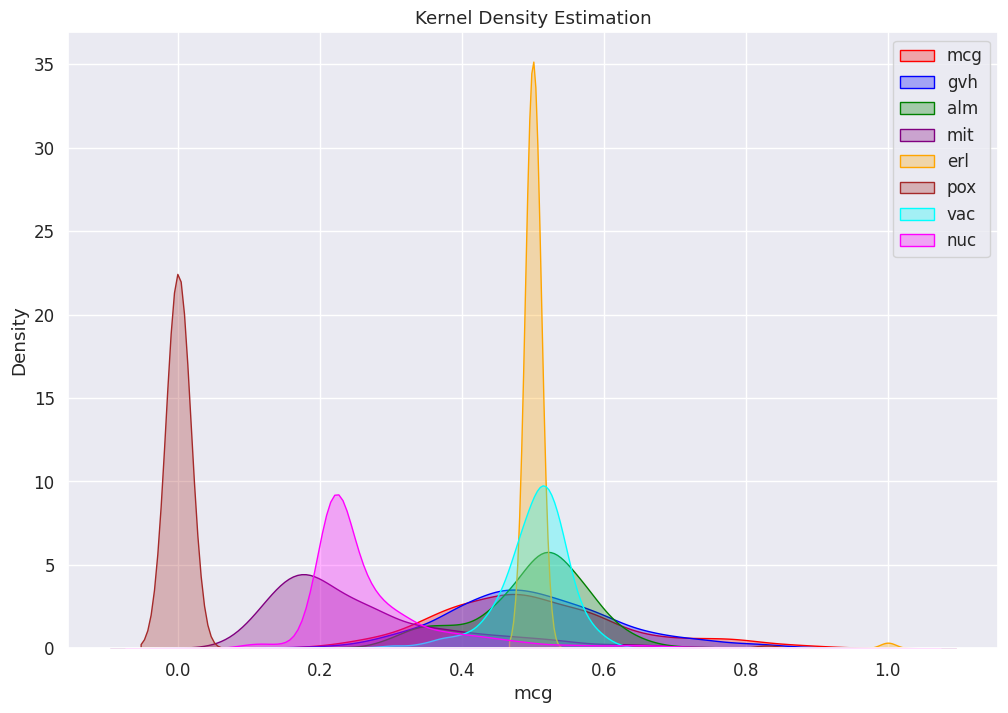

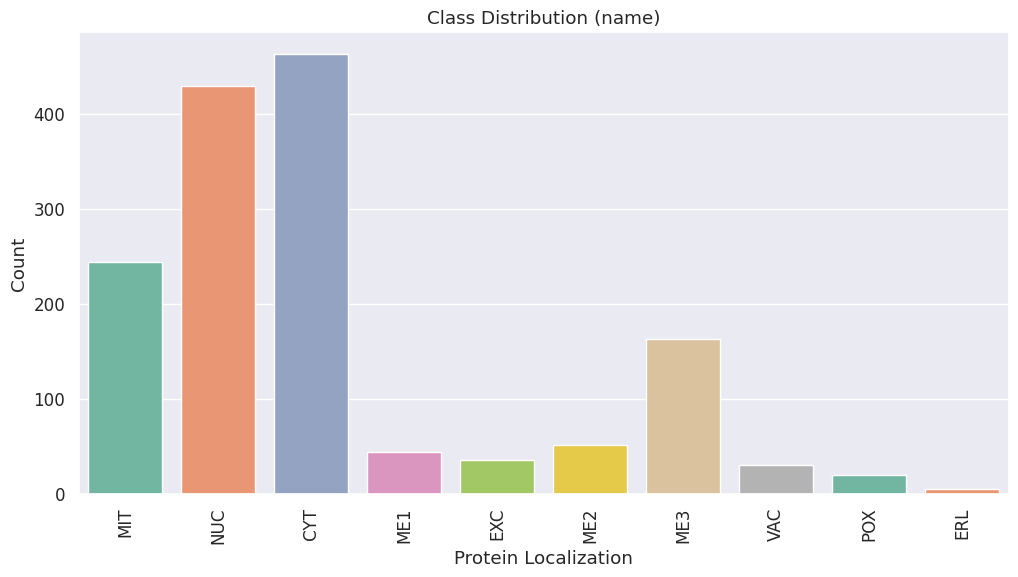

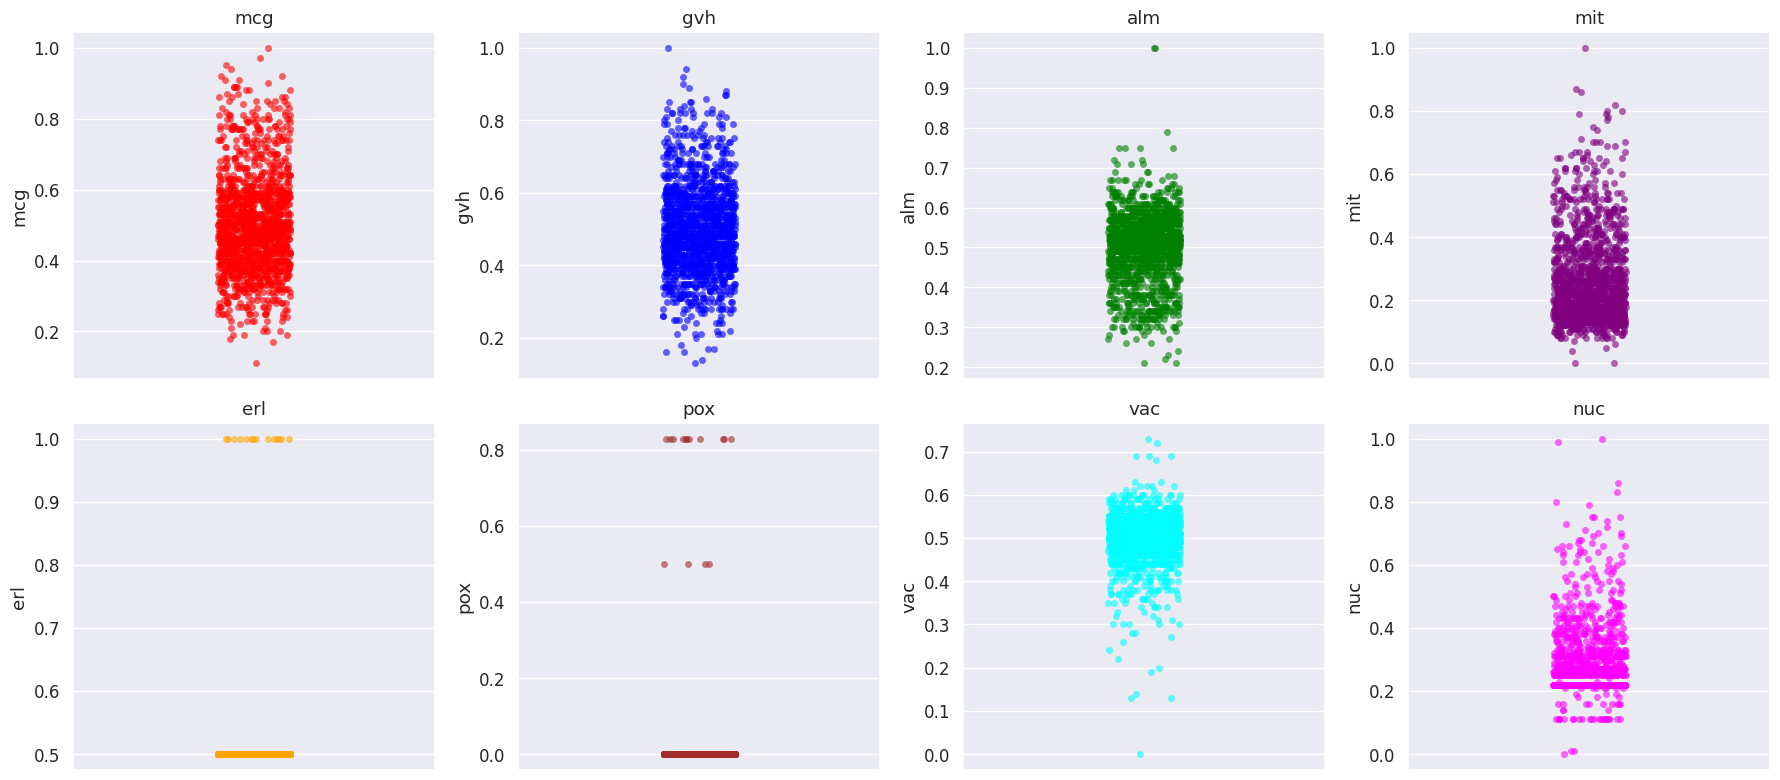

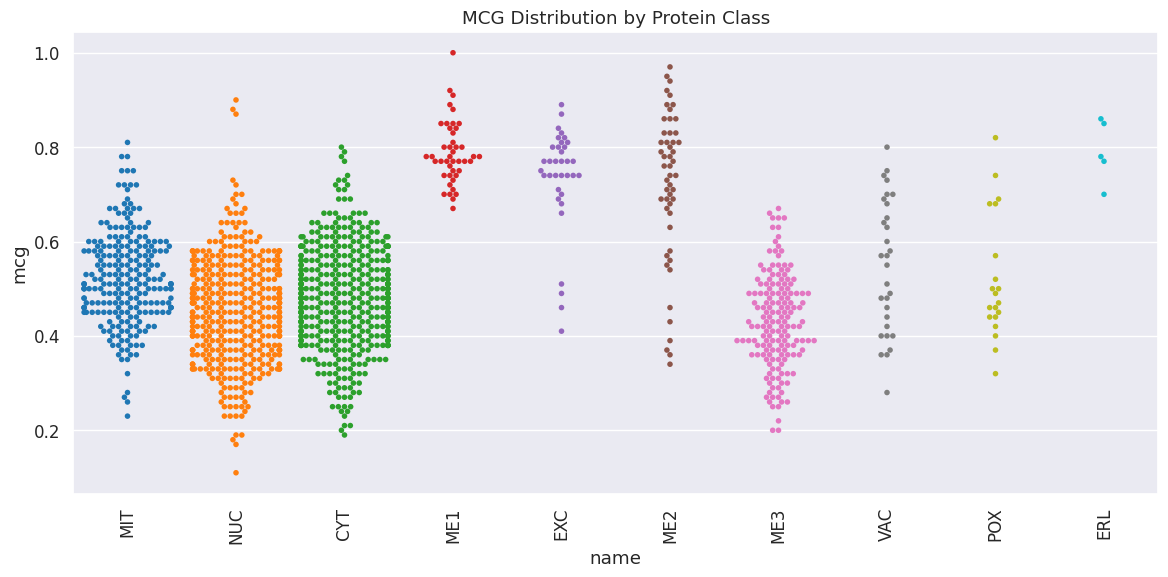

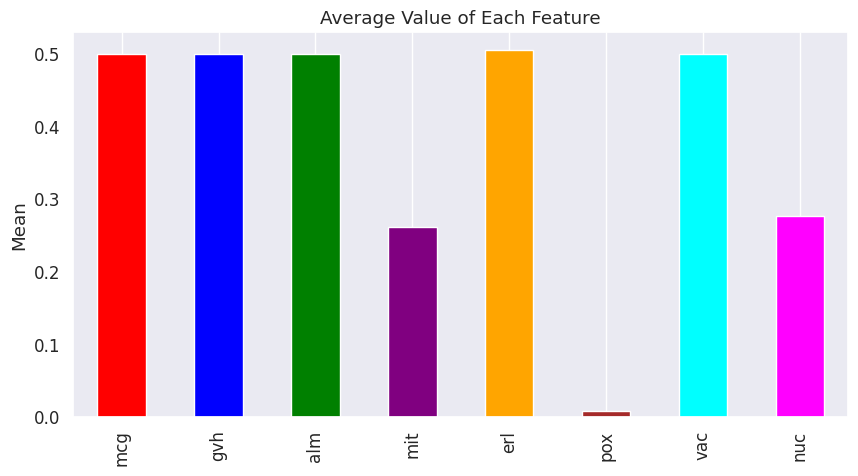

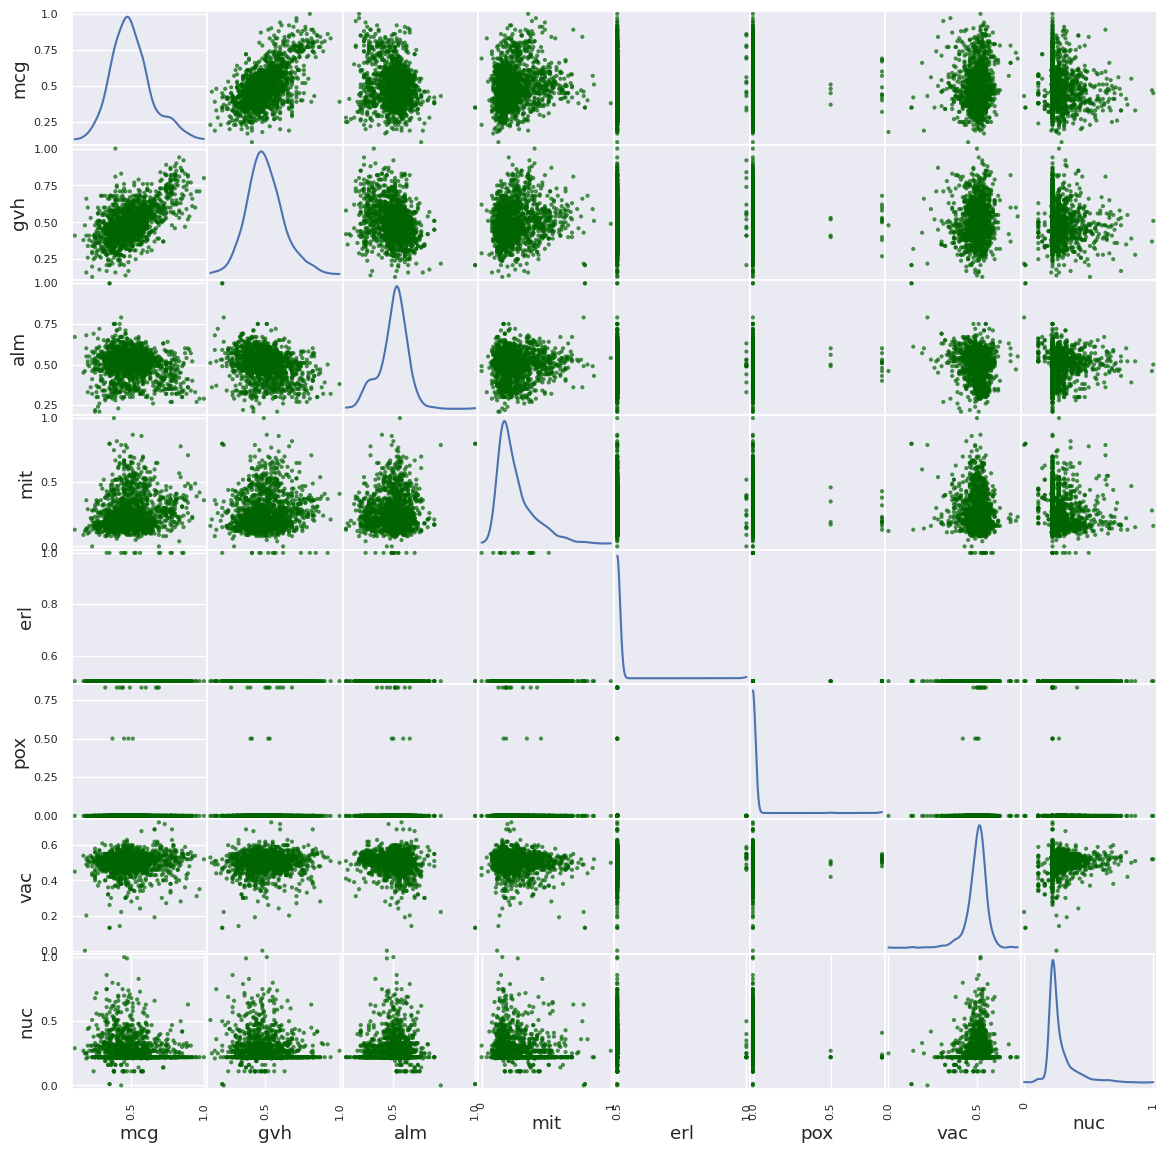

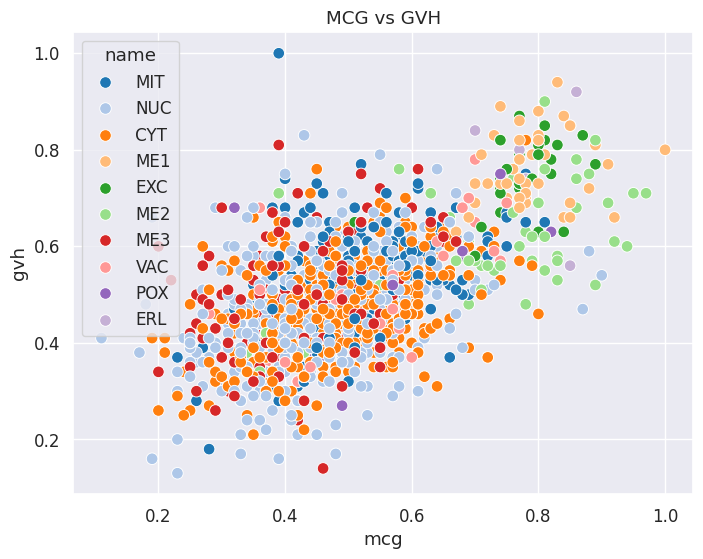

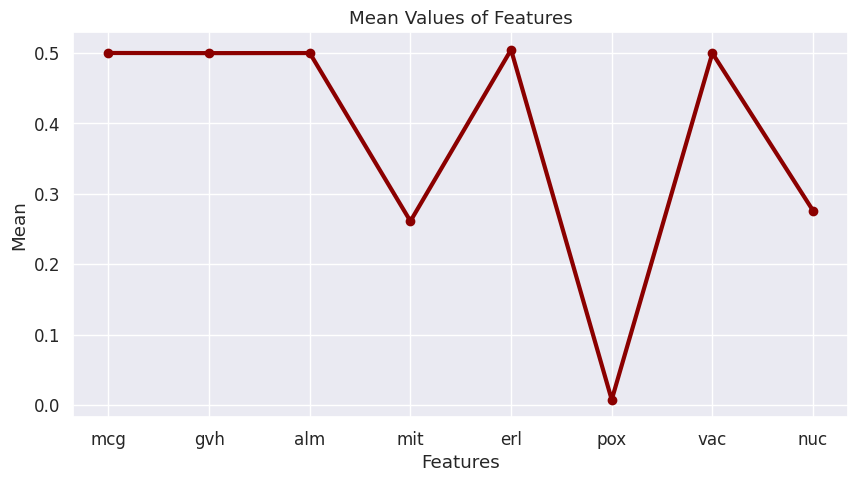

In [11]:

# Style
plt.style.use("ggplot")
sns.set(font_scale=1.1)

# -------------------------------
# 1. Dataset Information
# -------------------------------
print(df.head())
print(df.info())
print(df.describe())

# -------------------------------
# 2. Missing Values
# -------------------------------
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# -------------------------------
# 3. Histograms
# -------------------------------
numeric_cols = ['mcg','gvh','alm','mit','erl','pox','vac','nuc']

colors = ['red','blue','green','purple','orange','brown','cyan','magenta']

fig, axes = plt.subplots(2,4, figsize=(18,8))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, kde=True,
                 color=colors[i],
                 ax=axes[i//4,i%4])
    axes[i//4,i%4].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# -------------------------------
# 4. Boxplots
# -------------------------------
fig, axes = plt.subplots(2,4, figsize=(18,8))

for i,col in enumerate(numeric_cols):
    sns.boxplot(y=df[col],
                color=colors[i],
                ax=axes[i//4,i%4])
    axes[i//4,i%4].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# -------------------------------
# 5. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# -------------------------------
# 6. Pairplot
# -------------------------------
sns.pairplot(df[numeric_cols],
             corner=True,
             plot_kws={'color':'darkblue'})
plt.show()

# -------------------------------
# 7. Violin Plots
# -------------------------------
fig, axes = plt.subplots(2,4, figsize=(18,8))

for i,col in enumerate(numeric_cols):
    sns.violinplot(y=df[col],
                   color=colors[i],
                   ax=axes[i//4,i%4])
    axes[i//4,i%4].set_title(f'Violin Plot - {col}')

plt.tight_layout()
plt.show()

# -------------------------------
# 8. KDE Plots
# -------------------------------
plt.figure(figsize=(12,8))

for i,col in enumerate(numeric_cols):
    sns.kdeplot(df[col],
                fill=True,
                alpha=0.3,
                color=colors[i],
                label=col)

plt.legend()
plt.title("Kernel Density Estimation")
plt.show()

# -------------------------------
# 9. Count Plot (Target Column)
# -------------------------------
plt.figure(figsize=(12,6))

palette = sns.color_palette("Set2", df['name'].nunique())

sns.countplot(data=df,
              x='name',
              palette=palette)

plt.xticks(rotation=90)
plt.title("Class Distribution (name)")
plt.xlabel("Protein Localization")
plt.ylabel("Count")
plt.show()

# -------------------------------
# 10. Strip Plots
# -------------------------------
fig, axes = plt.subplots(2,4, figsize=(18,8))

for i,col in enumerate(numeric_cols):
    sns.stripplot(y=df[col],
                  color=colors[i],
                  alpha=0.6,
                  ax=axes[i//4,i%4])
    axes[i//4,i%4].set_title(col)

plt.tight_layout()
plt.show()

# -------------------------------
# 11. Swarm Plot
# -------------------------------
plt.figure(figsize=(14,6))
sns.swarmplot(data=df,
              x='name',
              y='mcg',
              palette='tab10',
              size=4)

plt.xticks(rotation=90)
plt.title("MCG Distribution by Protein Class")
plt.show()

# -------------------------------
# 12. Feature Means
# -------------------------------
feature_mean = df[numeric_cols].mean()

plt.figure(figsize=(10,5))
feature_mean.plot(kind='bar',
                  color=['red','blue','green','purple',
                         'orange','brown','cyan','magenta'])

plt.title("Average Value of Each Feature")
plt.ylabel("Mean")
plt.grid(axis='y')
plt.show()

# -------------------------------
# 13. Scatter Matrix
# -------------------------------
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[numeric_cols],
    figsize=(14,14),
    diagonal='kde',
    color='darkgreen',
    alpha=0.7
)

plt.show()

# -------------------------------
# 14. Scatter Plot
# -------------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='mcg',
    y='gvh',
    hue='name',
    palette='tab20',
    s=70
)

plt.title("MCG vs GVH")
plt.show()

# -------------------------------
# 15. Line Plot of Feature Means
# -------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    numeric_cols,
    feature_mean.values,
    marker='o',
    linewidth=3,
    color='darkred'
)

plt.title("Mean Values of Features")
plt.xlabel("Features")
plt.ylabel("Mean")
plt.grid(True)
plt.show()


## Features Engineering


Accuracy Score: 0.6229

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.68      0.62        93
           1       0.00      0.00      0.00         1
           2       0.40      0.29      0.33         7
           3       0.78      0.78      0.78         9
           4       0.44      0.40      0.42        10
           5       0.81      0.81      0.81        32
           6       0.66      0.59      0.62        49
           7       0.61      0.62      0.61        86
           8       1.00      0.25      0.40         4
           9       0.00      0.00      0.00         6

    accuracy                           0.62       297
   macro avg       0.53      0.44      0.46       297
weighted avg       0.61      0.62      0.61       297

ROC AUC Score (OvR): 0.8414


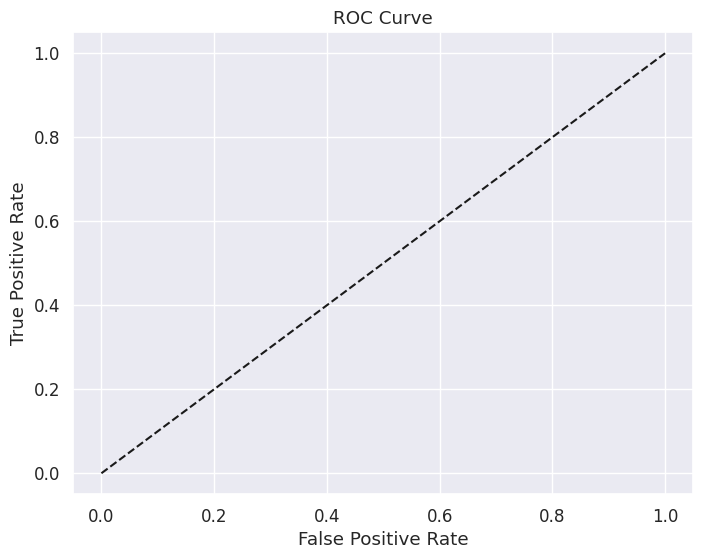

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Setup Mock Data (Replace with your actual DataFrame 'df')
# Assuming 'df' exists with the columns you provided
# df = pd.read_csv('your_data.csv') 

# 2. Define Features and Target
X = df.drop('name', axis=1)
y = df['name']

# 3. Label Encode the Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Data Splitting (CRITICAL: Do this BEFORE scaling to prevent leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Scaling (Fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Apply ML Algorithm (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# 8. Detailed Evaluation
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. ROC Curve (For Multi-class, we use One-vs-Rest approach)
# Note: roc_auc_score requires probabilities
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"ROC AUC Score (OvR): {roc_auc:.4f}")

# Plotting the ROC Curve (simplified example)
# For multiclass, ROC is typically plotted per class
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
